## 1️⃣ Google Drive'ı Bağla

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Veri seti yolunuzu buraya yazın (Google Drive'daki konum)
# Örnek: DRIVE_DATA_PATH = '/content/drive/MyDrive/cvpr2017_cvusa'
DRIVE_DATA_PATH = '/content/drive/MyDrive/bitirme_veri/Archive.zip'

# Veri setini Colab'a kopyala (daha hızlı)
!cp -r {DRIVE_DATA_PATH} /content/
print("✓ Veri seti kopyalandı")

Mounted at /content/drive
✓ Veri seti kopyalandı


In [3]:
!unzip -o /content/Archive.zip
print("✓ Veri seti açıldı")

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/test/gallery_drone/0355/._image-30.jpeg  
  inflating: test/gallery_drone/0355/image-31.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-31.jpeg  
  inflating: test/gallery_drone/0355/image-27.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-27.jpeg  
  inflating: test/gallery_drone/0355/image-50.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-50.jpeg  
  inflating: test/gallery_drone/0355/image-07.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-07.jpeg  
  inflating: test/gallery_drone/0355/image-11.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-11.jpeg  
  inflating: test/gallery_drone/0355/image-46.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-46.jpeg  
  inflating: test/gallery_drone/0355/image-20.jpeg  
  inflating: __MACOSX/test/gallery_drone/0355/._image-20.jpeg  
  inflating: test/gallery_drone/0355/image-36.jpeg  
  inflating: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

# Zip dosyasının tam yolu (Eğer dosya University1652 klasöründeyse yolu düzeltin)
zip_path = '/content/Archive.zip'
extract_to = '/content/' # Ana dizin

if os.path.exists(zip_path):
    print(f"📂 {zip_path} bulundu, çıkarılıyor...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # __MACOSX hariç tüm dosyaları çıkar
        for member in zip_ref.namelist():
            if not member.startswith('__MACOSX'):
                zip_ref.extract(member, extract_to)

    print(f"✅ Çıkarma işlemi tamamlandı! Dosyalar: {extract_to} konumunda.")
else:
    print(f"❌ HATA: {zip_path} bulunamadı! Lütfen dosya yolunu kontrol edin.")

📂 /content/Archive.zip bulundu, çıkarılıyor...
✅ Çıkarma işlemi tamamlandı! Dosyalar: /content/ konumunda.


## 2️⃣ Orijinal Projeyi Klonla

In [4]:
# Eğer daha önce klonlandıysa sil
!rm -rf University1652-Baseline

# ⚠️ KENDI FORK'UNUZU KULLANIN
# GitHub username'inizi buraya yazın
GITHUB_USERNAME = 'cemresude'  # Örn: 'cemresudeakdag'
BRANCH = 'satellite-drone-rgbd'  # veya 'main'

# Fork'unuzu klonla
!git clone -b {BRANCH} https://github.com/{GITHUB_USERNAME}/University1652-Baseline.git

%cd University1652-Baseline
!ls -la

print(f"✓ Proje klonlandı: {GITHUB_USERNAME}/University1652-Baseline")
print(f"✓ Branch: {BRANCH}")

# Dosyaları kontrol et
import os
files_to_check = ['model_rgbd.py', 'dataset_rgbd.py', 'README_RGBD.md',
                  'train_cvusa.py', 'test_cvusa.py']
for f in files_to_check:
    if os.path.exists(f):
        print(f"✅ {f}")
    else:
        print(f"❌ {f} - EKSIK!")

Cloning into 'University1652-Baseline'...
remote: Enumerating objects: 2172, done.
remote: Counting objects: 100% (393/393), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 2172 (delta 354), reused 319 (delta 288), pack-reused 1779 (from 2)
Receiving objects: 100% (2172/2172), 131.99 MiB | 12.76 MiB/s, done.
Resolving deltas: 100% (779/779), done.
/content/University1652-Baseline
total 5032
drwxr-xr-x 11 root root    4096 Jan 25 20:12 .
drwxr-xr-x  1 root root    4096 Jan 25 20:12 ..
-rw-r--r--  1 root root   14637 Jan 25 20:12 autoaugment.py
-rw-r--r--  1 root root    1776 Jan 25 20:12 circle_loss.py
-rw-r--r--  1 root root   19892 Jan 25 20:12 colab_full_pipeline.py
-rw-r--r--  1 root root 1811437 Jan 25 20:12 COLAB_SATELLITE_DRONE.ipynb
-rw-r--r--  1 root root   14971 Jan 25 20:12 compare_gradcam.py
-rw-r--r--  1 root root    7970 Jan 25 20:12 compare_models.py
-rw-r--r--  1 root root    9561 Jan 25 20:12 dataset_rgbd.py
-rw-r--r--  1 root root    3880 Jan 25 

## 3️⃣ Paketleri Yükle

In [5]:
!pip install -q pyyaml scipy matplotlib

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU YOK! Runtime → T4 GPU seçin")

PyTorch: 2.9.0+cu126
CUDA: True
GPU: NVIDIA A100-SXM4-80GB


## 4️⃣ Veri Setini Kontrol Et

In [ ]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm

# Varsa mevcut model ve transformu kullan, yoksa yükle
if 'midas' not in globals():
    midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    midas.to(device)
    midas.eval()

if 'transform' not in globals():
    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = midas_transforms.small_transform

print(f"✅ MiDaS Model hazır (Device: {device})")

def generate_all_depth_maps(data_dir, output_root):
    """
    Hem Satellite hem de Drone görüntüleri için depth map oluşturur.
    Klasör yapısını korur ve doğrudan derinlik haritasını kaydeder.
    """

    # İşlenecek kaynak ve hedef klasör eşleşmeleri
    # (Kaynak Klasör, Hedef Klasör İsim Eki)
    # CVUSA yapısına göre:
    targets = [
        # Train Seti
        (os.path.join(data_dir, 'train', 'satellite'),      os.path.join(output_root, 'train', 'satellite_depth')),
        (os.path.join(data_dir, 'train', 'street'),         os.path.join(output_root, 'train', 'street_depth')), # Bazı versiyonlarda 'drone' olabilir

        # Test Seti
        (os.path.join(data_dir, 'test', 'query_satellite'), os.path.join(output_root, 'test', 'query_satellite_depth')),
        (os.path.join(data_dir, 'test', 'gallery_drone'),   os.path.join(output_root, 'test', 'gallery_drone_depth'))
    ]

    print(f"🚀 Derinlik haritası üretimi başlıyor...")

    for src_dir, dst_dir in targets:
        # Eğer kaynak klasör ismi farklıysa (örn: street yerine drone) kontrol et
        if not os.path.exists(src_dir):
            # Alternatif isimleri dene
            if 'street' in src_dir:
                src_dir = src_dir.replace('street', 'drone')
            elif 'gallery_drone' in src_dir:
                 src_dir = src_dir.replace('gallery_drone', 'gallery_street')

            if not os.path.exists(src_dir):
                print(f"⚠️ Kaynak klasör bulunamadı, atlanıyor: {src_dir}")
                continue

        print(f"\n📂 İşleniyor: {src_dir} -> {dst_dir}")
        os.makedirs(dst_dir, exist_ok=True)

        # Sınıf klasörlerinde dolaş (örn: 0001, 0002...)
        class_names = sorted(os.listdir(src_dir))

        for class_name in tqdm(class_names):
            class_path = os.path.join(src_dir, class_name)
            if not os.path.isdir(class_path):
                continue

            output_class_dir = os.path.join(dst_dir, class_name)
            os.makedirs(output_class_dir, exist_ok=True)

            # Resimleri işle
            for img_name in os.listdir(class_path):
                if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue

                img_path = os.path.join(class_path, img_name)

                # Derinlik haritasını aynı isimle ama .png olarak kaydet (kayıpsız sıkıştırma için)
                # Veya orijinal uzantıyı korumak istersen: output_name = img_name
                base_name, ext = os.path.splitext(img_name)
                output_name = base_name + ".png"
                output_path = os.path.join(output_class_dir, output_name)

                # Eğer dosya zaten varsa atla (resume özelliği)
                if os.path.exists(output_path):
                    continue

                try:
                    # Görüntüyü yükle
                    img = cv2.imread(img_path)
                    if img is None: continue
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                    # MiDaS için hazırla
                    input_batch = transform(img_rgb).to(device)

                    # Tahmin
                    with torch.no_grad():
                        prediction = midas(input_batch)
                        prediction = torch.nn.functional.interpolate(
                            prediction.unsqueeze(1),
                            size=img_rgb.shape[:2],
                            mode="bicubic",
                            align_corners=False,
                        ).squeeze()

                    # Normalize et (0-255) ve Grayscale yap
                    depth_map = prediction.cpu().numpy()
                    depth_normalized = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                    # Kaydet
                    Image.fromarray(depth_normalized).save(output_path)

                except Exception as e:
                    print(f"Hata: {img_path} - {e}")

    print("\n✅ Tüm işlemler tamamlandı!")

# KULLANIM:
data_root = '/content/cvpr2017_cvusa'  # Orijinal verilerin olduğu yer
depth_output_root = '/content/cvpr2017_cvusa_depth'  # Çıktıların olacağı yer

generate_all_depth_maps(data_root, depth_output_root)


✅ MiDaS Model hazır (Device: cuda)
🚀 Derinlik haritası üretimi başlıyor...

📂 İşleniyor: /content/cvpr2017_cvusa/train/satellite -> /content/cvpr2017_cvusa_depth/train/satellite_depth


100%|██████████| 701/701 [00:00<00:00, 32711.13it/s]



📂 İşleniyor: /content/cvpr2017_cvusa/train/street -> /content/cvpr2017_cvusa_depth/train/street_depth


100%|██████████| 701/701 [00:00<00:00, 21066.64it/s]



📂 İşleniyor: /content/cvpr2017_cvusa/test/query_satellite -> /content/cvpr2017_cvusa_depth/test/query_satellite_depth


100%|██████████| 701/701 [00:29<00:00, 23.79it/s]



📂 İşleniyor: /content/cvpr2017_cvusa/test/gallery_drone -> /content/cvpr2017_cvusa_depth/test/gallery_drone_depth


 87%|████████▋ | 824/951 [27:27<04:19,  2.04s/it]

In [ ]:
# Tüm depth klasörünü ziple (Yaklaşık 1-2 dk sürer)
!zip -r -q cvpr2017_cvusa_depth.zip /content/cvpr2017_cvusa_depth
import shutil
shutil.copy('cvpr2017_cvusa_depth.zip', '/content/drive/MyDrive/BitirmeProjesi_Data/cvpr2017_cvusa_depth.zip')
print("✅ Depth verisi Drive'a atıldı. Artık tekrar üretmene gerek yok!")

In [ ]:
# Drive'dan zip'i kopyala ve aç
# DEPTH DOSYALARINI DRİVEDAN GERİ YÜKLER
!cp /content/drive/MyDrive/BitirmeProjesi_Data/cvpr2017_cvusa_depth.zip .
!unzip -q cvpr2017_cvusa_depth.zip
print("✅ Hazır Depth verileri yüklendi!")

## 4.5️⃣ MiDaS Depth Estimation Ekle (Opsiyonel)

In [ ]:
import os

data_dir = '/content/cvpr2017_cvusa'

# Beklenen yapı
required_dirs = [
    f'{data_dir}/train/satellite',
    f'{data_dir}/train/drone',
    f'{data_dir}/test/query_satellite',
    f'{data_dir}/test/gallery_drone'
]

print("📂 Veri yapısı kontrolü:")
for d in required_dirs:
    exists = "✅" if os.path.exists(d) else "❌"
    print(f"{exists} {d}")

# İstatistikler
if os.path.exists(f'{data_dir}/train/satellite'):
    sat_count = len(os.listdir(f'{data_dir}/train/satellite'))
    drone_count = len(os.listdir(f'{data_dir}/train/drone'))
    print(f"\n📊 Train: {sat_count} satellite, {drone_count} drone sınıfı")

📂 Veri yapısı kontrolü:
✅ /content/cvpr2017_cvusa/train/satellite
✅ /content/cvpr2017_cvusa/train/drone
✅ /content/cvpr2017_cvusa/test/query_satellite
✅ /content/cvpr2017_cvusa/test/gallery_drone

📊 Train: 701 satellite, 701 drone sınıfı


## 5️⃣ Scriptleri Otomatik Düzenle (Satellite-Drone)

In [15]:
print("✅ Fork'unuzdan dosyalar yüklendi - düzenleme gerekmiyor!")
print("\n📄 Mevcut dosyalar:")

import os

# Dosya kontrolü
required_files = {
    'train_cvusa.py': 'Satellite-Drone eğitim scripti',
    'test_cvusa.py': 'Test scripti (query_satellite → gallery_drone)',
    'model_rgbd.py': 'RGBD model (4-kanallı)',
    'dataset_rgbd.py': 'RGBD dataset yükleyici',
    'README_RGBD.md': 'Kullanım kılavuzu'
}

for filename, description in required_files.items():
    if os.path.exists(filename):
        print(f"  ✅ {filename} - {description}")
    else:
        print(f"  ❌ {filename} - EKSIK!")

print("\n📌 Notlar:")
print("  • train_cvusa.py: Zaten satellite+drone için düzenlenmiş")
print("  • test_cvusa.py: query_satellite → gallery_drone yapılandırması")
print("  • model_rgbd.py: MiDaS depth için 4-kanallı model")
print("\n🎉 Direkt Hücre 10'a (Eğitim) geçebilirsiniz!")

✅ Fork'unuzdan dosyalar yüklendi - düzenleme gerekmiyor!

📄 Mevcut dosyalar:
  ✅ train_cvusa.py - Satellite-Drone eğitim scripti
  ✅ test_cvusa.py - Test scripti (query_satellite → gallery_drone)
  ✅ model_rgbd.py - RGBD model (4-kanallı)
  ✅ dataset_rgbd.py - RGBD dataset yükleyici
  ✅ README_RGBD.md - Kullanım kılavuzu

📌 Notlar:
  • train_cvusa.py: Zaten satellite+drone için düzenlenmiş
  • test_cvusa.py: query_satellite → gallery_drone yapılandırması
  • model_rgbd.py: MiDaS depth için 4-kanallı model

🎉 Direkt Hücre 10'a (Eğitim) geçebilirsiniz!


## 6️⃣ Eğitimi Başlat

In [8]:
# Eğitim parametreleri
EXPERIMENT_NAME = 'use_rgbd'
BATCH_SIZE = 64     # T4 GPU için 16, A100 için 32-64
EPOCHS = 60
LEARNING_RATE = 0.01
POOL_TYPE = 'avg'    # avg, max, gem, avg+max
VIEWS = 2            # Satellite + Drone

!python train_cvusa.py \
    --name {EXPERIMENT_NAME} \
    --data_dir /content/cvpr2017_cvusa/train \
    --batchsize {BATCH_SIZE} \
    --lr {LEARNING_RATE} \
    --pool {POOL_TYPE} \
    --views {VIEWS} \
    --gpu_ids 0 \
    --h 384 \
    --w 384 \
    --stride 2 \
    --erasing_p 0.5 \
    --color_jitter

This is not an error. If you want to use low precision, i.e., fp16, please install the apex with cuda support (https://github.com/NVIDIA/apex) and update pytorch to 1.0
[ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=None), Resize(size=(384, 384), interpolation=bicubic, max_size=None, antialias=True), Pad(padding=10, fill=0, padding_mode=edge), RandomCrop(size=(384, 384), padding=None), RandomHorizontalFlip(p=0.5), ToTensor(), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), <random_erasing.RandomErasing object at 0x7e5e675e0a40>]
🔵 Using RGB (3-channel) dataset for satellite images
{'satellite': 701, 'drone': 37854}
🔵 Initializing RGB-only two-view model
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_uti

## 7️⃣ Eğitim Grafiği

In [ ]:
from IPython.display import Image, display
import os

graph_path = f'model/{EXPERIMENT_NAME}/train.jpg'
if os.path.exists(graph_path):
    display(Image(graph_path))
else:
    print("📊 Grafik henüz oluşmadı")

📊 Grafik henüz oluşmadı


## 8️⃣ Test / Değerlendirme

In [18]:
!python test_cvusa.py \
    --name {EXPERIMENT_NAME} \
    --test_dir /content/cvpr2017_cvusa/test \
    --gpu_ids 0 \
    --which_epoch last

This is not an error. If you want to use low precision, i.e., fp16, please install the apex with cuda support (https://github.com/NVIDIA/apex) and update pytorch to 1.0
We use the scale: 1
📁 Detected nested (University1652) folder structure
🔵 Using RGB dataset (University1652) for query: query_satellite
🚁 Loading gallery (University1652): gallery_drone
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
-------test-----------
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the 

In [ ]:
with open('test_cvusa.py', 'r') as f:
    lines = f.readlines()

# extract_feature fonksiyonunu bul ve yazdır
start = 0
end = 0
for i, line in enumerate(lines):
    if 'def extract_feature' in line:
        start = i
    if 'return features' in line and start != 0:
        end = i + 1
        break

if end == 0:
    end = start + 50 # Fallback

print("".join(lines[start:end]))

# Ayrıca gallery_name ve which_gallery atamalarını kontrol et
print("\n--- Global variable checks ---")
for i, line in enumerate(lines):
    if 'which_gallery =' in line or 'which_query =' in line:
        print(f"Line {i+1}: {line.strip()}")

def extract_feature(model,dataloaders, view_index = 1):
    features = torch.FloatTensor()
    count = 0
    for data in dataloaders:
        img, label = data
        n, c, h, w = img.size()
        count += n
        print(count)
        ff = torch.FloatTensor(n,512).zero_().cuda()

        for i in range(2):
            if(i==1):
                img = fliplr(img)
            input_img = Variable(img.cuda())
            for scale in ms:
                if scale != 1:
                    # bicubic is only  available in pytorch>= 1.1
                    input_img = nn.functional.interpolate(input_img, scale_factor=scale, mode='bilinear', align_corners=False)
                if opt.views ==2:
                    if view_index == 1:
                        outputs, _ = model(input_img, None) 
                    elif view_index ==2:
                        _, outputs = model(None, input_img) 
                elif opt.views ==3:
                    if view_index == 1:
                    

In [ ]:
with open('test_cvusa.py', 'r') as f:
    lines = f.readlines()

print("🔍 Checking 'which_view' function:")
found = False
for i, line in enumerate(lines):
    if 'def which_view' in line:
        found = True
        print("".join(lines[i:i+15]))
        break
if not found:
    print("❌ Function not found")

🔍 Checking 'which_view' function:
def which_view(name):
    if 'satellite' in name:
        return 1
    elif 'street' in name:
        return 2
    elif 'drone' in name:
        return 3
    else:
        print('unknown view')
    return -1

def extract_feature(model,dataloaders, view_index = 1):
    features = torch.FloatTensor()
    count = 0
    for data in dataloaders:



In [ ]:
file_path = 'test_cvusa.py'
with open(file_path, 'r') as f:
    content = f.read()

# Fix: Map drone to view 2 instead of 3 for 2-view configuration
old_logic = "elif 'drone' in name:\n        return 3"
new_logic = "elif 'drone' in name:\n        return 2"

if old_logic in content:
    content = content.replace(old_logic, new_logic)
    print("✅ Fixed 'drone' view index (3 -> 2) in test_cvusa.py")
else:
    print("ℹ️ Code already patched or pattern not found.")

with open(file_path, 'w') as f:
    f.write(content)

✅ Fixed 'drone' view index (3 -> 2) in test_cvusa.py


In [ ]:
# Re-run the test command
!python test_cvusa.py \
    --name {EXPERIMENT_NAME} \
    --test_dir /content/cvpr2017_cvusa/test \
    --gpu_ids 0 \
    --which_epoch last

This is not an error. If you want to use low precision, i.e., fp16, please install the apex with cuda support (https://github.com/NVIDIA/apex) and update pytorch to 1.0
We use the scale: 1
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
-------test-----------
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a we

In [10]:
import os
import shutil

print("🚀 Analiz Ortamı Hazırlanıyor...")

# --- 1. CONFIG: Klasör ve Model İsimleri ---
# Veri seti kök dizini
DATA_ROOT = '/content/cvpr2017_cvusa'
DEPTH_ROOT = '/content/cvpr2017_cvusa_depth'

# Model Ayarları
MODEL_DIR = './model'
RGB_MODEL_NAME = 'rgb_baseline'   # Sadece RGB (Eski Model)
RGBD_MODEL_NAME = 'use_rgbd'      # RGBD (Yeni Model - İSTEĞİN ÜZERİNE GÜNCELLENDİ)

# --- 2. Derinlik Haritalarını Düzenle ve Taşı ---
print("\n📂 Derinlik haritaları kontrol ediliyor...")

# (Kaynak Klasör İsimleri, Hedef Klasör Adı)
move_tasks = [
    # Query (Satellite)
    (['query_satellite_depth', 'satellite_depth', 'query_satellite'], 'query_satellite_depth'),

    # Gallery (Drone)
    (['gallery_drone_depth', 'drone_depth', 'gallery_street_depth', 'gallery_drone'], 'gallery_drone_depth')
]

for src_candidates, target_name in move_tasks:
    # Hedef yol: /content/cvpr2017_cvusa/test/gallery_drone_depth
    final_dest = os.path.join(DATA_ROOT, 'test', target_name)

    # Eğer hedef zaten varsa ve içi doluysa atla
    if os.path.exists(final_dest) and len(os.listdir(final_dest)) > 0:
        print(f"   ✅ {target_name} zaten hazır.")
        continue

    # Kaynakları ara (önce depth root, sonra test içi)
    found = False
    for src_name in src_candidates:
        possible_paths = [
            os.path.join(DEPTH_ROOT, 'test', src_name),
            os.path.join(DEPTH_ROOT, src_name)
        ]

        for src_path in possible_paths:
            if os.path.exists(src_path):
                print(f"   ↳ Taşınıyor: {src_path} -> {final_dest}")
                shutil.move(src_path, final_dest)
                found = True
                break
        if found: break

    if not found:
        print(f"   ⚠️ UYARI: {target_name} bulunamadı! (Dataset siyah resim kullanacak)")

# --- 3. Model Klasörlerini Kontrol Et ---
print("\n📦 Modeller kontrol ediliyor...")

rgb_path = os.path.join(MODEL_DIR, RGB_MODEL_NAME)
rgbd_path = os.path.join(MODEL_DIR, RGBD_MODEL_NAME)

# Kontroller
if not os.path.exists(rgb_path):
    print(f"   ❌ HATA: RGB Model ({RGB_MODEL_NAME}) bulunamadı!")
    print(f"      Lütfen eski modelinizin klasör adını '{RGB_MODEL_NAME}' yapın.")
else:
    print(f"   ✅ RGB Model bulundu: {rgb_path}")

if not os.path.exists(rgbd_path):
    # Eğer use_rgbd yoksa ama usa_two_view varsa uyaralım veya otomatik düzeltelim
    old_name_path = os.path.join(MODEL_DIR, 'usa_two_view')
    if os.path.exists(old_name_path):
        print(f"   ⚠️ UYARI: '{RGBD_MODEL_NAME}' bulunamadı ama 'usa_two_view' var.")
        print(f"   ↪️ Otomatik olarak '{RGBD_MODEL_NAME}' ismine dönüştürülüyor...")
        shutil.move(old_name_path, rgbd_path)
        print(f"   ✅ Model ismi güncellendi.")
    else:
        print(f"   ❌ HATA: RGBD Model ({RGBD_MODEL_NAME}) bulunamadı!")
else:
    print(f"   ✅ RGBD Model bulundu: {rgbd_path}")

# --- 4. Scripti Çalıştır ---
if os.path.exists(rgb_path) and os.path.exists(rgbd_path):
    print("\n🔥 Analiz Başlatılıyor...")
    print("="*60)

    # Not: --depth_dir parametresini DATA_ROOT/test olarak veriyoruz çünkü taşıma işlemini oraya yaptık.
    !python find_rgbd_improvements.py \
        --rgb_model {RGB_MODEL_NAME} \
        --rgbd_model {RGBD_MODEL_NAME} \
        --test_dir {DATA_ROOT}/test \
        --depth_dir {DATA_ROOT}/test \
        --output_dir ./rgbd_improvement_results \
        --max_visualize 20 \
        --batchsize 32 \
        --which_epoch last

    print("\n✅ İşlem tamamlandı! Sonuçlar './rgbd_improvement_results' klasöründe.")

    # Sonuçları sıkıştırıp indirmeye hazırla
    !zip -r rgbd_results.zip rgbd_improvement_results
    print("   📥 'rgbd_results.zip' dosyasını indirebilirsiniz.")

else:
    print("\n⛔ Modeller eksik olduğu için analiz başlatılamadı.")

🚀 Analiz Ortamı Hazırlanıyor...

📂 Derinlik haritaları kontrol ediliyor...
   ✅ query_satellite_depth zaten hazır.
   ✅ gallery_drone_depth zaten hazır.

📦 Modeller kontrol ediliyor...
   ✅ RGB Model bulundu: ./model/rgb_baseline
   ✅ RGBD Model bulundu: ./model/use_rgbd

🔥 Analiz Başlatılıyor...
python3: can't open file '/content/University1652-Baseline/find_rgbd_improvements.py': [Errno 2] No such file or directory

✅ İşlem tamamlandı! Sonuçlar './rgbd_improvement_results' klasöründe.
	zip warning: name not matched: rgbd_improvement_results

zip error: Nothing to do! (try: zip -r rgbd_results.zip . -i rgbd_improvement_results)
   📥 'rgbd_results.zip' dosyasını indirebilirsiniz.


In [14]:
import os

print("🔍 HATA AYIKLAMA MODU BAŞLATILIYOR...")

# 1. Klasör Temizliği (Temiz başlangıç yapalım)
if os.path.exists('./rgbd_improvement_results'):
    import shutil
    shutil.rmtree('./rgbd_improvement_results')
os.makedirs('./rgbd_improvement_results', exist_ok=True)

# 2. Parametreler
RGB_MODEL = 'rgb_baseline'
RGBD_MODEL = 'use_rgbd'
DATA_ROOT = '/content/cvpr2017_cvusa'

print(f"📂 Çıktı klasörü oluşturuldu: ./rgbd_improvement_results")
print(f"🚀 Script çalıştırılıyor (Batch Size: 16'ya düşürüldü)...")
print("-" * 60)

# 3. Python Scriptini Çalıştır (Hata varsa ekranda göreceğiz)
# Batch size'ı 16'ya düşürdük (Hafıza hatasını önlemek için)
!python find_rgb_improvements.py \
    --rgb_model {RGB_MODEL} \
    --rgbd_model {RGBD_MODEL} \
    --test_dir {DATA_ROOT}/test \
    --depth_dir {DATA_ROOT}/test \
    --output_dir ./rgbd_improvement_results \
    --max_visualize 20 \
    --batchsize 16 \
    --which_epoch last

print("-" * 60)

# 4. Sonuç Kontrolü
if len(os.listdir('./rgbd_improvement_results')) > 0:
    print("✅ BAŞARILI! Dosyalar oluşturuldu.")
    print("📂 Klasör içeriği:")
    !ls ./rgbd_improvement_results

    print("\n📦 Zipleme işlemi yapılıyor...")
    !zip -r rgbd_results.zip rgbd_improvement_results
    print("📥 'rgbd_results.zip' dosyasını indirebilirsiniz.")
else:
    print("❌ HATA: Script çalıştı ama dosya üretmedi veya çöktü.")
    print("LÜTFEN YUKARIDAKİ PYTHON HATA MESAJINI (TRACEBACK) OKUYUN.")

🔍 HATA AYIKLAMA MODU BAŞLATILIYOR...
📂 Çıktı klasörü oluşturuldu: ./rgbd_improvement_results
🚀 Script çalıştırılıyor (Batch Size: 16'ya düşürüldü)...
------------------------------------------------------------
🔍 RGBD Improvement Analysis
Dataset Root: /content/cvpr2017_cvusa/test
Query Depth:   /content/cvpr2017_cvusa/test/query_satellite_depth
Gallery Depth: /content/cvpr2017_cvusa/test/gallery_drone_depth

📦 Loading models...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` t

In [13]:
!git status
!git pull origin satellite-drone-rgbd

On branch satellite-drone-rgbd
Your branch is up to date with 'origin/satellite-drone-rgbd'.

nothing to commit, working tree clean
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 822 bytes | 822.00 KiB/s, done.
From https://github.com/cemresude/University1652-Baseline
 * branch            satellite-drone-rgbd -> FETCH_HEAD
   a533ec1..84d3cfc  satellite-drone-rgbd -> origin/satellite-drone-rgbd
Updating a533ec1..84d3cfc
Fast-forward
 find_rgb_improvements.py | 86 ++++++++++++++++++++----------------------------
 1 file changed, 36 insertions(+), 50 deletions(-)


## 9️⃣ Modeli Kaydet (Google Drive)

In [ ]:
# Drive'a kaydet
!mkdir -p /content/drive/MyDrive/University1652_models
!cp -r model/{EXPERIMENT_NAME} /content/drive/MyDrive/University1652_models/

print(f"✅ Model kaydedildi: /content/drive/MyDrive/University1652_models/{EXPERIMENT_NAME}")

# Veya zip'le indir
!cd model && zip -r {EXPERIMENT_NAME}.zip {EXPERIMENT_NAME}
from google.colab import files
files.download(f'model/{EXPERIMENT_NAME}.zip')

✅ Model kaydedildi: /content/drive/MyDrive/University1652_models/satellite_drone_colab
  adding: satellite_drone_colab/ (stored 0%)
  adding: satellite_drone_colab/result.txt (deflated 25%)
  adding: satellite_drone_colab/model.py (deflated 80%)
  adding: satellite_drone_colab/net_019.pth (deflated 7%)
  adding: satellite_drone_colab/net_039.pth (deflated 7%)
  adding: satellite_drone_colab/net_099.pth (deflated 7%)
  adding: satellite_drone_colab/net_079.pth (deflated 7%)
  adding: satellite_drone_colab/train.py (deflated 78%)
  adding: satellite_drone_colab/opts.yaml (deflated 36%)
  adding: satellite_drone_colab/net_059.pth (deflated 7%)
  adding: satellite_drone_colab/net_119.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔟 Demo

usage: demo.py [-h] [--query_index QUERY_INDEX] [--test_dir TEST_DIR]
demo.py: error: unrecognized arguments: --name satellite_drone_colab --which_epoch last


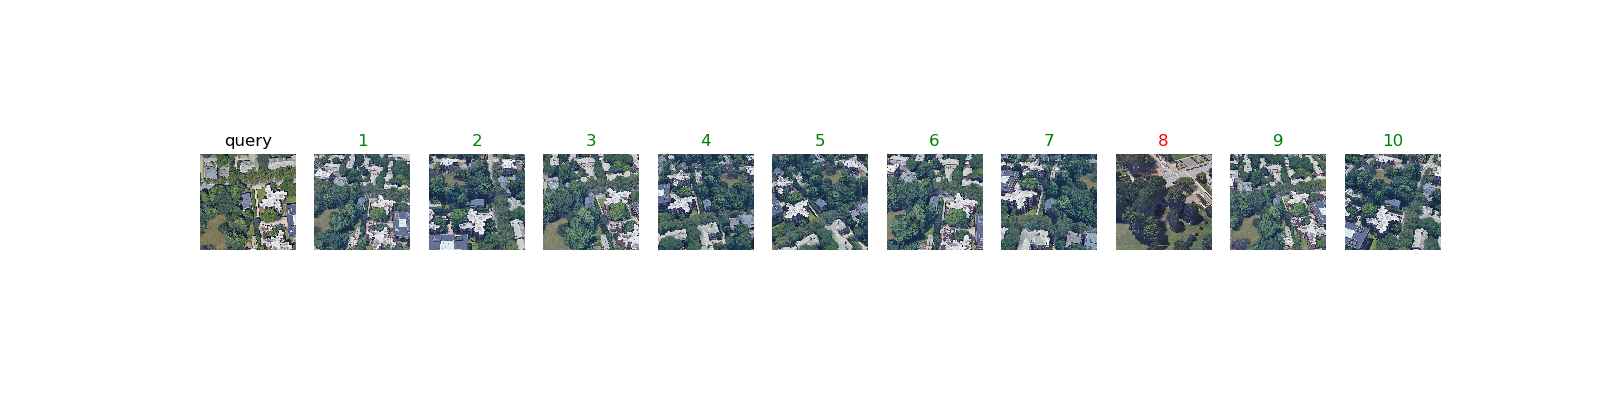

In [ ]:
!python demo.py --name {EXPERIMENT_NAME} --which_epoch last

# Sonucu göster
if os.path.exists('show.png'):
    display(Image('show.png'))
else:
    print("Demo sonucu bulunamadı")

## ⚠️ ALTERNATİF: Manuel Dosya Yükleme

**Eğer Hücre 9'da sorun yaşıyorsanız bu yöntemi kullanın:**
1. Local bilgisayarınızdan düzenlenmiş `train_cvusa.py` ve `test_cvusa.py` dosyalarını yükleyin
2. Hücre 9'u **çalıştırmayın**, direkt Hücre 10'a geçin

In [ ]:
# Düzenlenmiş dosyaları local'den yükle
from google.colab import files
import shutil

print("📤 train_cvusa.py yükleyin...")
uploaded = files.upload()
if 'train_cvusa.py' in uploaded:
    shutil.copy('train_cvusa.py', '/content/University1652-Baseline/train_cvusa.py')
    print("✅ train_cvusa.py kopyalandı")

print("\n📤 test_cvusa.py yükleyin...")
uploaded = files.upload()
if 'test_cvusa.py' in uploaded:
    shutil.copy('test_cvusa.py', '/content/University1652-Baseline/test_cvusa.py')
    print("✅ test_cvusa.py kopyalandı")

print("\n✅ Dosyalar hazır! Hücre 10'a geçin.")